In [191]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
import platform
from scipy.stats import chi2_contingency
import pandas as pd

pd.set_option('display.float_format',"{:.2f}".format)

# OS에 따라 다른 폰트 지정
if platform.system() == 'Darwin':   # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':  # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:  # Linux (예: Colab, Ubuntu)
    plt.rcParams['font.family'] = 'NanumGothic'

In [192]:
df = pd.read_csv("data_eda_v2.csv", encoding='utf-8', parse_dates=['issue_d', 'earliest_cr_line'])

In [193]:
display(df.head())
display(df.columns)
print(df.shape)

,id,loan_status,default_rate,loan_amnt,term,int_rate,installment,purpose,issue_d,loan_income_ratio,...,num_accts_ever_120_pd,num_accts_ever_120_f,tot_cur_bal,tot_cur_bal_f,avg_bal_per_acc,percent_bc_gt_75,percent_bc_gt_75_f,tot_hi_cred_lim,tot_hi_cred_lim_f,collections_12_mths_ex_med
0,68407277,Fully Paid,0,3600.00,36 months,13.99,123.03,debt_consolidation,2015-12-01,0.07,...,2.00,0,144904.00,0,11146.46,0.00,0,178050.00,0,0.00
1,68355089,Fully Paid,0,24700.00,36 months,11.99,820.28,small_business,2015-12-01,0.38,...,0.00,0,204396.00,0,5378.84,7.70,0,314017.00,0,0.00
2,68476807,Fully Paid,0,10400.00,60 months,22.45,289.91,major_purchase,2015-12-01,0.10,...,0.00,0,331730.00,0,9478.00,60.00,0,439570.00,0,0.00
3,68426831,Fully Paid,0,11950.00,36 months,13.44,405.18,debt_consolidation,2015-12-01,0.35,...,0.00,0,12798.00,0,2133.00,100.00,0,16900.00,0,0.00
4,68476668,Fully Paid,0,20000.00,36 months,9.17,637.58,debt_consolidation,2015-12-01,0.11,...,0.00,0,360358.00,0,13346.59,100.00,0,388852.00,0,0.00


Index(['id', 'loan_status', 'default_rate', 'loan_amnt', 'term', 'int_rate',
       'installment', 'purpose', 'issue_d', 'loan_income_ratio', 'emp_title',
       'emp_length', 'emp_length_group', 'home_ownership', 'annual_inc',
       'annual_inc_clip', 'annual_inc_log', 'verification_status', 'dti',
       'fico_avg', 'fico_group', 'earliest_cr_line', 'cr_hist_months', 'grade',
       'sub_grade', 'delinq_2yrs', 'inq_last_6mths', 'pub_rec',
       'pub_rec_bankruptcies', 'tax_liens', 'acc_now_delinq', 'delinq_amnt',
       'open_acc', 'total_acc', 'num_sats', 'mort_acc', 'revol_bal',
       'revol_util', 'revol_util_f', 'pct_tl_nvr_dlq', 'pct_tl_nvr_dlq_f',
       'num_accts_ever_120_pd', 'num_accts_ever_120_f', 'tot_cur_bal',
       'tot_cur_bal_f', 'avg_bal_per_acc', 'percent_bc_gt_75',
       'percent_bc_gt_75_f', 'tot_hi_cred_lim', 'tot_hi_cred_lim_f',
       'collections_12_mths_ex_med'],
      dtype='object')

(1251189, 51)


-------------------------------

1. 각 신용컬럼별 카이제곱 + 크래머v계수 확인
- default_rate = 0/1로 부실률을 구함 - 범주형
- 각 컬럼 - 범주형

In [194]:
df['pd120_ratio'] = df['num_accts_ever_120_pd'] / df['total_acc'].replace(0, np.nan) #전체 신용계좌중에서 한번이라도 120이상 연체된 계좌의 비율

cols = ['dti', 'cr_hist_months', 'delinq_2yrs', 'inq_last_6mths', 'pub_rec', 'pub_rec_bankruptcies',
        'tax_liens', 'acc_now_delinq', 'delinq_amnt', 'open_acc', 'total_acc', 'num_sats', 'mort_acc', 'revol_bal', 
        'revol_util', 'pct_tl_nvr_dlq', 'num_accts_ever_120_pd', 'tot_cur_bal', 'percent_bc_gt_75', 'tot_hi_cred_lim', 'collections_12_mths_ex_med'
        ,'avg_bal_per_acc', 'pd120_ratio']

def check_cols(df, cols, target='default_rate', q=10):
    result = []

    for col in cols:
        temp = df[[col, target]].copy()

        temp['group'] = pd.qcut(temp[col], q=q, duplicates='drop')

        # 교차표
        tab = pd.crosstab(temp['group'], temp[target])

        if tab.shape[0] < 2 or tab.shape[1] < 2:
            continue
        
        # 카이제곱
        chi2, p, dof, expected = chi2_contingency(tab)

        # 크래머V
        n = tab.values.sum()
        r, c = tab.shape
        cramers_v = np.sqrt(chi2 / (n * (min(r, c) - 1)))

        result.append([col, p, cramers_v])

    result_df = pd.DataFrame(result, columns=['col', 'p_value', 'cramers_v'])
    result_df = result_df.sort_values('cramers_v', ascending=False).reset_index(drop=True)

    return result_df

result_df = check_cols(df, cols)
display(result_df)

,col,p_value,cramers_v
0,dti,0.00,0.11
1,tot_hi_cred_lim,0.00,0.08
2,tot_cur_bal,0.00,0.08
3,avg_bal_per_acc,0.00,0.08
4,mort_acc,0.00,0.08
5,percent_bc_gt_75,0.00,0.07
6,revol_util,0.00,0.06
7,inq_last_6mths,0.00,0.06
8,cr_hist_months,0.00,0.04
9,open_acc,0.00,0.03


1. dti 0.11
2. tot_hi_cred_lim 0.08 # 신용계좌의 신용한도
3. tot_cur_bal 0.08 # 모든 신용계좌의 총 잔액
4. avg_bal_per_acc 0.08 # 계좌당 잔액 (빚)
5. mort_acc 0.08 #주택담보대출
6. percent_bc_gt_75 0.07 #카드한도 75%이상 사용
7. revol_util 0.06 #리볼빙 잔액
8. inq_last_6mths 0.06 #신용조회 횟수(최근 6개월)
9. cr_hist_months 0.04 #첫 신용계좌 생성일

In [195]:
# [2], [3] 겹치는거같아 상관계수 확인
# 두 컬럼은 수치형 변수이기 때문에 피어슨 상관계수 사용

display(df[['tot_hi_cred_lim', 'tot_cur_bal']].corr())#피어슨
display(df[['tot_hi_cred_lim', 'tot_cur_bal']].corr(method='kendall')) #켄달
display(df[['tot_hi_cred_lim', 'tot_cur_bal']].corr(method='spearman')) #스피어만

#0.97로 높은 상관관계를 보였으며, tot cur bar 가 더 직관적인 컬럼이라고 판단되어 tot_hi_cred_lim 컬럼은 점수에서 제외하기로 하였다.

,tot_hi_cred_lim,tot_cur_bal
tot_hi_cred_lim,1.00,0.97
tot_cur_bal,0.97,1.00


,tot_hi_cred_lim,tot_cur_bal
tot_hi_cred_lim,1.00,0.88
tot_cur_bal,0.88,1.00


,tot_hi_cred_lim,tot_cur_bal
tot_hi_cred_lim,1.00,0.97
tot_cur_bal,0.97,1.00


In [196]:
# [6], [7] 겹치는거같아 상관계수 확인
# 두 컬럼은 수치형 변수이기 때문에 피어슨 상관계수 사용

display(df[['percent_bc_gt_75', 'revol_util']].corr())#피어슨
display(df[['percent_bc_gt_75', 'revol_util']].corr(method='kendall')) #켄달
display(df[['percent_bc_gt_75', 'revol_util']].corr(method='spearman')) #스피어만

#0.72로 높은 상관계수를 보였으며, revol_util이 더 직관적인 컬럼이라고 판단되어 percent_bc_gt_75 컬럼은 점수에서 제외하기로 하였다.

,percent_bc_gt_75,revol_util
percent_bc_gt_75,1.00,0.72
revol_util,0.72,1.00


,percent_bc_gt_75,revol_util
percent_bc_gt_75,1.00,0.56
revol_util,0.56,1.00


,percent_bc_gt_75,revol_util
percent_bc_gt_75,1.00,0.73
revol_util,0.73,1.00


1. dti 0.11
2. [삭제]tot_hi_cred_lim 0.08 # 신용계좌의 신용한도 - 3번과 상관계수 0.97, 겹칠가능성이 커서 삭제
3. tot_cur_bal 0.08 # 모든 신용계좌의 총 잔액
4. [파생컬럼] avg_bal_per_acc 0.08 # 계좌당 잔액 (빚)
5. [삭제] mort_acc 0.08 #주택담보대출 -> 단독 해석에 한계가 있으며 (home_ownership 컬럼과교차분석) 해석구조가 달라 공동신청자처럼 필요시 별도로 분석이 필요한것같아 제외시켰다
6. [삭제] percent_bc_gt_75 0.07 #카드한도 75%이상 사용
7. revol_util 0.06 #리볼빙 잔액
8. inq_last_6mths 0.06 #신용조회 횟수(최근 6개월)
9. cr_hist_months 0.04 #첫 신용계좌 생성일




-----------------------------------------

### [유진분석]
- 36.revol_util 0.06
- 30.inq_last_6mths 0.07
- [파생컬럼] avg_bal_per_acc = tot_cur_bal / total_acc = 계좌당 잔액(빚)  = 0.08

### [윤서분석] 
- 25.dti 0.109
- 63.tot_cur_bal 0.08
- 109.percent_bc_gt_75 0.07


---------------------------------------------

# 분석전 규칙

1. 인원수로 나눠지는 qcut 방식과 컬럼 값 기준으로 나눠지는 cut방식중 cut방식 채용
- 인원을 기준으로 나눠버리면 비슷하거나 똑같은 값의 사람들의 리스크율이 달라질수있다고 생각되어 cut방식으로 산정
- 특이컬럼은 qcut방식으로 사용
- cut방식 특성상 표본 부족으로 이상치가 발견될수있어 해당구간은 최대 3% 이상 맞추고, 그 구간은 부실율을 평균내어 산정

--------------------------------------------

## revol_util 분석

In [197]:
df['revol_util'].value_counts()

revol_util
0.00      6044
57.00     2546
58.00     2511
53.00     2506
54.00     2506
          ... 
155.30       1
116.40       1
126.30       1
184.60       1
119.30       1
Name: count, Length: 1282, dtype: int64

In [198]:
# cut 10구간
df['revol_util_cut10'] = pd.cut(
    df['revol_util'],
    bins=[-np.inf, 20, 30, 40, 50, 60, 70, 75, 85, np.inf]
)

# qcut 10구간
df['revol_util_qcut10'] = pd.qcut(
    df['revol_util'],
    q=10,
    duplicates='drop'
)


print('===== FICO vs revol_util (cut 10구간) 표본수 =====')
count_cut = pd.pivot_table(
    df,
    values='default_rate',
    index='fico_group',
    columns='revol_util_cut10',
    aggfunc='count',
    observed=False
)

display(count_cut)

print('===== FICO vs revol_util (qcut 10구간) 표본수 =====')
count_qcut = pd.pivot_table(
    df,
    values='default_rate',
    index='fico_group',
    columns='revol_util_qcut10',
    aggfunc='count',
    observed=False
)

display(count_qcut)

print('===== FICO vs revol_util (cut 10구간) 각 등급 내 비율(%) =====')
pct_cut = pd.crosstab(
    df['fico_group'],
    df['revol_util_cut10'],
    normalize='index'
).round(4) * 100

display(pct_cut.round(2))

print('===== FICO vs revol_util (cut 10구간) 부실률 =====')
pivot_cut = pd.pivot_table(
    df,
    values='default_rate',
    index='fico_group',
    columns='revol_util_cut10',
    aggfunc='mean',
    observed=False
).round(3)
display(pivot_cut)

===== FICO vs revol_util (cut 10구간) 표본수 =====


revol_util_cut10,"(-inf, 20.0]","(20.0, 30.0]","(30.0, 40.0]","(40.0, 50.0]","(50.0, 60.0]","(60.0, 70.0]","(70.0, 75.0]","(75.0, 85.0]","(85.0, inf]"
fico_group,,,,,,,,,
excellent,12500,863,160,69,50,9,2,3,1
fair,9985,12310,20036,28244,35236,38482,18795,31913,33062
good,69132,81248,119237,134730,137305,122855,54189,90387,88636
very good,48285,26342,16868,9467,5021,2827,850,1191,899


===== FICO vs revol_util (qcut 10구간) 표본수 =====


revol_util_qcut10,"(-0.001, 18.6]","(18.6, 29.3]","(29.3, 37.5]","(37.5, 45.0]","(45.0, 52.1]","(52.1, 59.1]","(59.1, 66.6]","(66.6, 74.8]","(74.8, 84.9]","(84.9, 892.3]"
fico_group,,,,,,,,,,
excellent,12219,1117,161,69,48,23,14,2,3,1
fair,8760,12373,15320,19061,21874,25025,28585,31118,32436,33511
good,60695,82429,94229,98024,97829,96389,94582,92196,91617,89729
very good,44081,29022,15005,8937,5249,3347,2380,1596,1222,911


===== FICO vs revol_util (cut 10구간) 각 등급 내 비율(%) =====


revol_util_cut10,"(-inf, 20.0]","(20.0, 30.0]","(30.0, 40.0]","(40.0, 50.0]","(50.0, 60.0]","(60.0, 70.0]","(70.0, 75.0]","(75.0, 85.0]","(85.0, inf]"
fico_group,,,,,,,,,
excellent,91.53,6.32,1.17,0.51,0.37,0.07,0.01,0.02,0.01
fair,4.38,5.40,8.79,12.38,15.45,16.87,8.24,13.99,14.50
good,7.70,9.05,13.28,15.01,15.29,13.69,6.04,10.07,9.87
very good,43.21,23.57,15.09,8.47,4.49,2.53,0.76,1.07,0.80


===== FICO vs revol_util (cut 10구간) 부실률 =====


revol_util_cut10,"(-inf, 20.0]","(20.0, 30.0]","(30.0, 40.0]","(40.0, 50.0]","(50.0, 60.0]","(60.0, 70.0]","(70.0, 75.0]","(75.0, 85.0]","(85.0, inf]"
fico_group,,,,,,,,,
excellent,0.06,0.04,0.06,0.09,0.06,0.00,0.00,0.00,0.00
fair,0.22,0.23,0.25,0.26,0.27,0.27,0.27,0.27,0.27
good,0.18,0.19,0.19,0.20,0.20,0.20,0.20,0.21,0.22
very good,0.11,0.10,0.09,0.08,0.09,0.08,0.09,0.08,0.09


--------------------------------------------------------

### train / test 구분하여 train으로만 각 구간 및 risk_score 설정

In [199]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["default_rate"]   # 또는 loan_status를 0/1로 만든 타깃 컬럼명
)

#기존 코드들 활용으로 train_df를 df로 재정의.
df = train_df.copy()

#### revol_util 컬럼 최종 - cut기준
0. cut 기준은 pcut구간을 참고하여 만듬
1. excellent 기준은 30.0~ 을 한번에 묶기 - 부실율 30~ 구간 평균
2. very good 컬럼은 50.0 ~ 을 한번에 묶기 - 부실률 50~구간의 평균
3. good 컬럼은 70~ 이상을 한번에 묶기 - 부실률 70~ 구간의 평균
4. fair 컬럼은 모든구간 4%이상이기때문에 그대로

In [200]:
# 1. 동일 구간 설정
revol_bins = [-np.inf, 20, 30, 40, 50, 60, 70, 75, 85, np.inf]

df['revol_util_cut'] = pd.cut(df['revol_util'], bins=revol_bins)
test_df['revol_util_cut'] = pd.cut(test_df['revol_util'], bins=revol_bins)

# 2. df에서 구간별 리스크 점수표 생성
revol_score_table = (
    df.groupby(['fico_group', 'revol_util_cut'], observed=False)['default_rate']
      .mean()
      .reset_index()
      .rename(columns={'default_rate': 'revol_util_risk_score'})
)

display(revol_score_table)

# 3. test/train에 리스크 점수 붙이기
test_df = test_df.merge(
    revol_score_table,
    on=['fico_group', 'revol_util_cut'],
    how='left'
)
df = df.merge(
    revol_score_table,
    on=['fico_group', 'revol_util_cut'],
    how='left'
)
# 확인
display(test_df[['fico_group', 'revol_util', 'revol_util_cut', 'revol_util_risk_score']].head())
display(df[['fico_group', 'revol_util', 'revol_util_cut', 'revol_util_risk_score']].head())

,fico_group,revol_util_cut,revol_util_risk_score
0,excellent,"(-inf, 20.0]",0.06
1,excellent,"(20.0, 30.0]",0.05
2,excellent,"(30.0, 40.0]",0.07
3,excellent,"(40.0, 50.0]",0.07
4,excellent,"(50.0, 60.0]",0.05
5,excellent,"(60.0, 70.0]",0.00
6,excellent,"(70.0, 75.0]",0.00
7,excellent,"(75.0, 85.0]",0.00
8,excellent,"(85.0, inf]",0.00
9,fair,"(-inf, 20.0]",0.22


,fico_group,revol_util,revol_util_cut,revol_util_risk_score
0,fair,60.20,"(60.0, 70.0]",0.27
1,good,23.10,"(20.0, 30.0]",0.19
2,good,33.50,"(30.0, 40.0]",0.19
3,good,78.90,"(75.0, 85.0]",0.21
4,good,32.10,"(30.0, 40.0]",0.19


,fico_group,revol_util,revol_util_cut,revol_util_risk_score
0,very good,17.40,"(-inf, 20.0]",0.11
1,good,70.40,"(70.0, 75.0]",0.20
2,good,68.50,"(60.0, 70.0]",0.21
3,good,70.20,"(70.0, 75.0]",0.20
4,fair,41.80,"(40.0, 50.0]",0.26


----------------------------------------------

## inq_last_6mths_cut10 컬럼

In [201]:
df['inq_last_6mths'].value_counts()

#0~8까지의 숫자, 0이 대부분이라 0은 따로 빼주고 cut 10구간산정

inq_last_6mths
0.00    575833
1.00    272991
2.00    100099
3.00     36913
4.00     10729
5.00      3699
6.00       685
8.00         1
7.00         1
Name: count, dtype: int64

In [202]:
# cut 10구간
df['inq_last_6mths_cut'] = pd.cut(
    df['inq_last_6mths'],
    bins=[-np.inf, 0, 1, 2, 3, 4, 5, np.inf]
)

# qcut 10구간
df['inq_last_6mths_qcut'] = pd.qcut(
    df['inq_last_6mths'],
    q=9,
    duplicates='drop'
)


print('===== FICO vs inq_last_6mths (cut 구간) 표본수 =====')
count_cut = pd.pivot_table(
    df,
    values='default_rate',
    index='fico_group',
    columns='inq_last_6mths_cut',
    aggfunc='count',
    observed=False
)

display(count_cut)

print('===== FICO vs inq_last_6mths (qcut 구간) 표본수 =====')
count_qcut = pd.pivot_table(
    df,
    values='default_rate',
    index='fico_group',
    columns='inq_last_6mths_qcut',
    aggfunc='count',
    observed=False
)

display(count_qcut)

print('===== FICO vs inq_last_6mths (cut 구간) 각 등급 내 비율(%) =====')
pct_cut = pd.crosstab(
    df['fico_group'],
    df['inq_last_6mths_cut'],
    normalize='index'
).round(4) * 100

display(pct_cut.round(2))

print('===== FICO vs inq_last_6mths (cut 10구간) 부실률 =====')
pivot_cut = pd.pivot_table(
    df,
    values='default_rate',
    index='fico_group',
    columns='inq_last_6mths_cut',
    aggfunc='mean',
    observed=False
).round(3)
display(pivot_cut)





===== FICO vs inq_last_6mths (cut 구간) 표본수 =====


inq_last_6mths_cut,"(-inf, 0.0]","(0.0, 1.0]","(1.0, 2.0]","(2.0, 3.0]","(3.0, 4.0]","(4.0, 5.0]","(5.0, inf]"
fico_group,,,,,,,
excellent,7865,2282,586,194,46,18,6
fair,93348,54109,22606,8903,2668,911,127
good,416743,194998,70174,25555,7388,2541,487
very good,57877,21602,6733,2261,627,229,67


===== FICO vs inq_last_6mths (qcut 구간) 표본수 =====


inq_last_6mths_qcut,"(-0.001, 1.0]","(1.0, 2.0]","(2.0, 8.0]"
fico_group,,,
excellent,10147,586,264
fair,147457,22606,12609
good,611741,70174,35971
very good,79479,6733,3184


===== FICO vs inq_last_6mths (cut 구간) 각 등급 내 비율(%) =====


inq_last_6mths_cut,"(-inf, 0.0]","(0.0, 1.0]","(1.0, 2.0]","(2.0, 3.0]","(3.0, 4.0]","(4.0, 5.0]","(5.0, inf]"
fico_group,,,,,,,
excellent,71.52,20.75,5.33,1.76,0.42,0.16,0.05
fair,51.10,29.62,12.38,4.87,1.46,0.50,0.07
good,58.05,27.16,9.78,3.56,1.03,0.35,0.07
very good,64.74,24.16,7.53,2.53,0.70,0.26,0.07


===== FICO vs inq_last_6mths (cut 10구간) 부실률 =====


inq_last_6mths_cut,"(-inf, 0.0]","(0.0, 1.0]","(1.0, 2.0]","(2.0, 3.0]","(3.0, 4.0]","(4.0, 5.0]","(5.0, inf]"
fico_group,,,,,,,
excellent,0.05,0.07,0.11,0.15,0.15,0.17,0.33
fair,0.25,0.27,0.29,0.31,0.32,0.30,0.27
good,0.18,0.21,0.24,0.26,0.28,0.29,0.25
very good,0.08,0.11,0.16,0.19,0.20,0.22,0.19


------------------------------------------------

####  inq_last_6mths  컬럼

0. cut 기준은 pcut구간을 참고하여 만듬
1. excellent 컬럼은 2~ 구간을 한번에 묶기 (부실률의 차이가 꽤 크기 때문에 3~으로 묶어줌)
2. very good 컬럼은 3~ 구간을 한번에 묶기 (3~ 의 평균
3. good 컬럼은 2~ 구간을 한번에 묶기
4. fair 컬럼은 4이상인것 묶기

In [203]:
# ★ 공유 inq_last_6mths_risk_score

# 동일 구간 설정
inq_bins = [-np.inf, 0, 1, 2, 3, 4, 5, np.inf]

df['inq_last_6mths_cut'] = pd.cut(
    df['inq_last_6mths'],
    bins=inq_bins
)

test_df['inq_last_6mths_cut'] = pd.cut(
    test_df['inq_last_6mths'],
    bins=inq_bins
)
# 점수 컬럼 초기화
df['inq_last_6mths_risk_score'] = np.nan

# =========================
# 1) fair : 4이상인거 묶기
# =========================
df.loc[df['fico_group'] == 'fair', 'inq_last_6mths_risk_score'] = (
    df.loc[df['fico_group'] == 'fair']
      .groupby('inq_last_6mths_cut', observed=False)['default_rate']
      .transform('mean')
)

df.loc[
    (df['fico_group'] == 'fair') & (df['inq_last_6mths'] >= 4),
    'inq_last_6mths_risk_score'
] = df.loc[
    (df['fico_group'] == 'fair') & (df['inq_last_6mths'] >= 4),
    'default_rate'
].mean()

# =========================
# 2) good : 2 이상 묶기
# =========================
df.loc[df['fico_group'] == 'good', 'inq_last_6mths_risk_score'] = (
    df.loc[df['fico_group'] == 'good']
      .groupby('inq_last_6mths_cut', observed=False)['default_rate']
      .transform('mean')
)

df.loc[
    (df['fico_group'] == 'good') & (df['inq_last_6mths'] >= 2),
    'inq_last_6mths_risk_score'
] = df.loc[
    (df['fico_group'] == 'good') & (df['inq_last_6mths'] >= 2),
    'default_rate'
].mean()

# =========================
# 3) very good : 3 이상 묶기
# =========================
df.loc[df['fico_group'] == 'very good', 'inq_last_6mths_risk_score'] = (
    df.loc[df['fico_group'] == 'very good']
      .groupby('inq_last_6mths_cut', observed=False)['default_rate']
      .transform('mean')
)

df.loc[
    (df['fico_group'] == 'very good') & (df['inq_last_6mths'] >= 3),
    'inq_last_6mths_risk_score'
] = df.loc[
    (df['fico_group'] == 'very good') & (df['inq_last_6mths'] >= 3),
    'default_rate'
].mean()

# =========================
# 4) excellent : 2 이상 묶기
# =========================
df.loc[df['fico_group'] == 'excellent', 'inq_last_6mths_risk_score'] = (
    df.loc[df['fico_group'] == 'excellent']
      .groupby('inq_last_6mths_cut', observed=False)['default_rate']
      .transform('mean')
)

df.loc[
    (df['fico_group'] == 'excellent') & (df['inq_last_6mths'] >= 2),
    'inq_last_6mths_risk_score'
] = df.loc[
    (df['fico_group'] == 'excellent') & (df['inq_last_6mths'] >= 2),
    'default_rate'
].mean()


#train기반 리스크표 생성
inq_score_table = (
    df.groupby(['fico_group','inq_last_6mths_cut'], observed=False)['inq_last_6mths_risk_score']
      .mean()
      .reset_index()
)

display(inq_score_table)

#test에도 적용
test_df = test_df.merge(
    inq_score_table,
    on=['fico_group','inq_last_6mths_cut'],
    how='left'
)

,fico_group,inq_last_6mths_cut,inq_last_6mths_risk_score
0,excellent,"(-inf, 0.0]",0.05
1,excellent,"(0.0, 1.0]",0.08
2,excellent,"(1.0, 2.0]",0.12
3,excellent,"(2.0, 3.0]",0.12
4,excellent,"(3.0, 4.0]",0.12
5,excellent,"(4.0, 5.0]",0.12
6,excellent,"(5.0, inf]",0.12
7,fair,"(-inf, 0.0]",0.25
8,fair,"(0.0, 1.0]",0.27
9,fair,"(1.0, 2.0]",0.29


------------------------------------------------

## avg_bal_per_acc컬럼

In [204]:
df['avg_bal_per_acc'].value_counts()


avg_bal_per_acc
0.00        271
821.00       23
747.00       22
706.00       22
1392.00      22
           ... 
11492.83      1
16103.89      1
31891.46      1
6299.03       1
9039.36       1
Name: count, Length: 813677, dtype: int64

In [205]:
df['avg_bal_per_acc'].describe()

#0이 가장많지만 실제로 찍어본결과 범위계수가 훨신 많았음

count   1000951.00
mean       5811.34
std        6808.08
min           0.00
25%        1482.40
50%        3353.29
75%        7988.13
max      394236.00
Name: avg_bal_per_acc, dtype: float64

In [206]:
# cut 10구간
df['avg_bal_per_acc_cut'] = pd.cut(
    df['avg_bal_per_acc'],
    bins=[-0.1, 0, 823.406, 1344.364, 1933.217, 2755.0, 4124.167, 6132.85, 8710.567, 12945.724, np.inf]
)

# pcut 10구간
df['avg_bal_per_acc_qcut'] = pd.qcut(
    df['avg_bal_per_acc'],
    q=9,
    duplicates='drop'
)

df['avg_bal_per_acc_qnum'] = pd.qcut(
    df['avg_bal_per_acc'],
    q=9,
    labels=False,
    duplicates='drop'
) + 1


print('===== FICO vs avg_bal_per_acc (cut 구간) 표본수 =====')
count_cut = pd.pivot_table(
    df,
    values='default_rate',
    index='fico_group',
    columns='avg_bal_per_acc_cut',
    aggfunc='count',
    observed=False
)

display(count_cut)

print('===== FICO vs avg_bal_per_acc (qcut 구간) 표본수 =====')
count_qcut = pd.pivot_table(
    df,
    values='default_rate',
    index='fico_group',
    columns='avg_bal_per_acc_qcut',
    aggfunc='count',
    observed=False
)

display(count_qcut)

print('===== FICO vs avg_bal_per_acc (qcut 구간) 각 등급 내 비율(%) =====')
pct_cut = pd.crosstab(
    df['fico_group'],
    df['avg_bal_per_acc_qcut'],
    normalize='index'
).round(4) * 100

display(pct_cut.round(2))

print('===== FICO vs avg_bal_per_acc (qcut 10구간) 부실률 =====')
pivot_cut = pd.pivot_table(
    df,
    values='default_rate',
    index='fico_group',
    columns='avg_bal_per_acc_qcut',
    aggfunc='mean',
    observed=False
).round(3)
display(pivot_cut)





===== FICO vs avg_bal_per_acc (cut 구간) 표본수 =====


avg_bal_per_acc_cut,"(-0.1, 0.0]","(0.0, 823.406]","(823.406, 1344.364]","(1344.364, 1933.217]","(1933.217, 2755.0]","(2755.0, 4124.167]","(4124.167, 6132.85]","(6132.85, 8710.567]","(8710.567, 12945.724]","(12945.724, inf]"
fico_group,,,,,,,,,,
excellent,5,1207,727,644,665,968,1444,1618,1630,2089
fair,23,29481,25439,23465,21698,19913,17593,16058,15107,13895
good,121,70611,77076,79672,81203,81412,81537,81930,82336,81988
very good,122,9621,7730,7543,7493,8780,10928,11907,12003,13269


===== FICO vs avg_bal_per_acc (qcut 구간) 표본수 =====


avg_bal_per_acc_qcut,"(-0.001, 823.51]","(823.51, 1345.687]","(1345.687, 1934.1]","(1934.1, 2758.0]","(2758.0, 4131.88]","(4131.88, 6136.682]","(6136.682, 8707.213]","(8707.213, 12946.544]","(12946.544, 394236.0]"
fico_group,,,,,,,,,
excellent,1213,730,644,661,977,1439,1614,1631,2088
fair,29514,25496,23425,21730,19938,17540,16009,15128,13892
good,70746,77249,79607,81322,81511,81323,81719,82440,81969
very good,9744,7742,7540,7507,8788,10914,11875,12018,13268


===== FICO vs avg_bal_per_acc (qcut 구간) 각 등급 내 비율(%) =====


avg_bal_per_acc_qcut,"(-0.001, 823.51]","(823.51, 1345.687]","(1345.687, 1934.1]","(1934.1, 2758.0]","(2758.0, 4131.88]","(4131.88, 6136.682]","(6136.682, 8707.213]","(8707.213, 12946.544]","(12946.544, 394236.0]"
fico_group,,,,,,,,,
excellent,11.03,6.64,5.86,6.01,8.88,13.09,14.68,14.83,18.99
fair,16.16,13.96,12.82,11.90,10.91,9.60,8.76,8.28,7.60
good,9.85,10.76,11.09,11.33,11.35,11.33,11.38,11.48,11.42
very good,10.90,8.66,8.43,8.40,9.83,12.21,13.28,13.44,14.84


===== FICO vs avg_bal_per_acc (qcut 10구간) 부실률 =====


avg_bal_per_acc_qcut,"(-0.001, 823.51]","(823.51, 1345.687]","(1345.687, 1934.1]","(1934.1, 2758.0]","(2758.0, 4131.88]","(4131.88, 6136.682]","(6136.682, 8707.213]","(8707.213, 12946.544]","(12946.544, 394236.0]"
fico_group,,,,,,,,,
excellent,0.10,0.07,0.08,0.07,0.06,0.06,0.05,0.05,0.05
fair,0.24,0.28,0.29,0.29,0.28,0.26,0.23,0.23,0.21
good,0.20,0.22,0.23,0.23,0.23,0.20,0.18,0.17,0.15
very good,0.13,0.12,0.12,0.13,0.11,0.10,0.08,0.08,0.07


-------------------------------------

##### avg_bal_per_acc 컬럼은 qcut으로 사용 (0비중 작음 / 범위 절대값보다는 qcut 사용)

In [207]:
# df에서 qcut 경계값 추출
df['avg_bal_per_acc_qcut'], avg_bal_bins = pd.qcut(
    df['avg_bal_per_acc'],
    q=9,
    duplicates='drop',
    retbins=True
)

df['avg_bal_per_acc_qnum'] = pd.qcut(
    df['avg_bal_per_acc'],
    q=9,
    labels=False,
    duplicates='drop'
) + 1

# test_df에는 df에서 구한 동일 경계값 적용
test_df['avg_bal_per_acc_qcut'] = pd.cut(
    test_df['avg_bal_per_acc'],
    bins=avg_bal_bins,
    include_lowest=True
)

# test_df의 qnum도 같은 경계값 기준으로 생성
test_df['avg_bal_per_acc_qnum'] = pd.cut(
    test_df['avg_bal_per_acc'],
    bins=avg_bal_bins,
    labels=False,
    include_lowest=True
) + 1

In [208]:
# 점수 컬럼 초기화
df['avg_bal_per_acc_risk_score'] = np.nan

# =========================
# 1) fair : 5구간 이하 묶기
# =========================
df.loc[df['fico_group'] == 'fair', 'avg_bal_per_acc_risk_score'] = (
    df.loc[df['fico_group'] == 'fair']
      .groupby('avg_bal_per_acc_qcut', observed=False)['default_rate']
      .transform('mean')
)

df.loc[
    (df['fico_group'] == 'fair') & (df['avg_bal_per_acc_qnum'] <= 5),
    'avg_bal_per_acc_risk_score'
] = df.loc[
    (df['fico_group'] == 'fair') & (df['avg_bal_per_acc_qnum'] <= 5),
    'default_rate'
].mean()

# =========================
# 2) good : 5구간 이하 묶기
# =========================
df.loc[df['fico_group'] == 'good', 'avg_bal_per_acc_risk_score'] = (
    df.loc[df['fico_group'] == 'good']
      .groupby('avg_bal_per_acc_qcut', observed=False)['default_rate']
      .transform('mean')
)

df.loc[
    (df['fico_group'] == 'good') & (df['avg_bal_per_acc_qnum'] <= 5),
    'avg_bal_per_acc_risk_score'
] = df.loc[
    (df['fico_group'] == 'good') & (df['avg_bal_per_acc_qnum'] <= 5),
    'default_rate'
].mean()

# =========================
# 3) very good : 4구간 이하 묶기
# =========================
df.loc[df['fico_group'] == 'very good', 'avg_bal_per_acc_risk_score'] = (
    df.loc[df['fico_group'] == 'very good']
      .groupby('avg_bal_per_acc_qcut', observed=False)['default_rate']
      .transform('mean')
)

df.loc[
    (df['fico_group'] == 'very good') & (df['avg_bal_per_acc_qnum'] <= 4),
    'avg_bal_per_acc_risk_score'
] = df.loc[
    (df['fico_group'] == 'very good') & (df['avg_bal_per_acc_qnum'] <= 4),
    'default_rate'
].mean()

# =========================
# 4) excellent : 4구간 이하 묶기
# =========================
df.loc[df['fico_group'] == 'excellent', 'avg_bal_per_acc_risk_score'] = (
    df.loc[df['fico_group'] == 'excellent']
      .groupby('avg_bal_per_acc_qcut', observed=False)['default_rate']
      .transform('mean')
)

df.loc[
    (df['fico_group'] == 'excellent') & (df['avg_bal_per_acc_qnum'] <= 4),
    'avg_bal_per_acc_risk_score'
] = df.loc[
    (df['fico_group'] == 'excellent') & (df['avg_bal_per_acc_qnum'] <= 4),
    'default_rate'
].mean()


# 점수표 생성
avg_bal_score_table = (
    df.groupby(['fico_group', 'avg_bal_per_acc_qcut'], observed=False)['avg_bal_per_acc_risk_score']
      .mean()
      .reset_index()
)

display(avg_bal_score_table)

test_df = test_df.merge(
    avg_bal_score_table,
    on=['fico_group', 'avg_bal_per_acc_qcut'],
    how='left'
)

display(
    test_df[
        [
            'fico_group',
            'avg_bal_per_acc',
            'avg_bal_per_acc_qcut',
            'avg_bal_per_acc_qnum',
            'avg_bal_per_acc_risk_score'
        ]
    ].head()
)

,fico_group,avg_bal_per_acc_qcut,avg_bal_per_acc_risk_score
0,excellent,"(-0.001, 823.51]",0.08
1,excellent,"(823.51, 1345.687]",0.08
2,excellent,"(1345.687, 1934.1]",0.08
3,excellent,"(1934.1, 2758.0]",0.08
4,excellent,"(2758.0, 4131.88]",0.06
5,excellent,"(4131.88, 6136.682]",0.06
6,excellent,"(6136.682, 8707.213]",0.05
7,excellent,"(8707.213, 12946.544]",0.05
8,excellent,"(12946.544, 394236.0]",0.05
9,fair,"(-0.001, 823.51]",0.28


,fico_group,avg_bal_per_acc,avg_bal_per_acc_qcut,avg_bal_per_acc_qnum,avg_bal_per_acc_risk_score
0,fair,2790.55,"(2758.0, 4131.88]",5,0.28
1,good,1860.59,"(1345.687, 1934.1]",3,0.22
2,good,2767.53,"(2758.0, 4131.88]",5,0.22
3,good,13116.88,"(12946.544, 394236.0]",9,0.15
4,good,6067.72,"(4131.88, 6136.682]",6,0.20


---------------------------------------------------------

In [209]:
# =========================================
# 0. 전제 확인
# =========================================
required_cols = ['fico_group', 'dti', 'tot_cur_bal', 'percent_bc_gt_75', 'default_rate']
missing_df_cols = [col for col in required_cols if col not in df.columns]
missing_test_cols = [col for col in required_cols if col not in test_df.columns]

if missing_df_cols:
    raise ValueError(f"다음 컬럼이 df에 없습니다: {missing_df_cols}")

if missing_test_cols:
    raise ValueError(f"다음 컬럼이 test_df에 없습니다: {missing_test_cols}")


# =========================================
# 1. 기존 컬럼 정리
# =========================================
drop_cols = [
    'dti_bin', 'tot_cur_bal_bin', 'percent_bc_gt_75_bin',
    'dti_risk_score', 'tot_cur_bal_risk_score', 'percent_bc_gt_75_risk_score',
    'risk_score', 'risk_score_qcut'
]

for col in drop_cols:
    if col in df.columns:
        df.drop(columns=col, inplace=True)
    if col in test_df.columns:
        test_df.drop(columns=col, inplace=True)


# =========================================
# 2. 학습용(df) / 적용용(test_df) 동일 bin 생성
# =========================================

# 2-1. DTI
dti_bins = [-np.inf, 10, 20, 30, np.inf]
dti_labels = ['<=10', '10~20', '20~30', '30+']

df['dti_bin'] = pd.cut(
    df['dti'],
    bins=dti_bins,
    labels=dti_labels
)

test_df['dti_bin'] = pd.cut(
    test_df['dti'],
    bins=dti_bins,
    labels=dti_labels
)

# 2-2. tot_cur_bal
tot_cur_bal_bins = [-np.inf, 50000, 200000, np.inf]
tot_cur_bal_labels = ['<=50k', '50k~200k', '200k+']

df['tot_cur_bal_bin'] = pd.cut(
    df['tot_cur_bal'],
    bins=tot_cur_bal_bins,
    labels=tot_cur_bal_labels
)

test_df['tot_cur_bal_bin'] = pd.cut(
    test_df['tot_cur_bal'],
    bins=tot_cur_bal_bins,
    labels=tot_cur_bal_labels
)

# 2-3. percent_bc_gt_75
bc_bins = [-np.inf, 33.3, 100]
bc_labels = ['<=33.3', '33.3+']

df['percent_bc_gt_75_bin'] = pd.cut(
    df['percent_bc_gt_75'],
    bins=bc_bins,
    labels=bc_labels
)

test_df['percent_bc_gt_75_bin'] = pd.cut(
    test_df['percent_bc_gt_75'],
    bins=bc_bins,
    labels=bc_labels
)


# =========================================
# 3. 확인용 교차표 함수
# =========================================
def check_fico_bin_table(data, bin_col):
    print(f"\n{'='*100}")
    print(f"[{bin_col}] FICO 그룹 x 구간별 표본수")
    count_tbl = pd.pivot_table(
        data,
        values='default_rate',
        index='fico_group',
        columns=bin_col,
        aggfunc='count',
        observed=False
    )
    display(count_tbl)

    print(f"\n[{bin_col}] FICO 그룹 x 구간별 각 등급 내 비율(%)")
    pct_tbl = pd.crosstab(
        data['fico_group'],
        data[bin_col],
        normalize='index'
    ).round(4) * 100
    display(pct_tbl.round(2))

    print(f"\n[{bin_col}] FICO 그룹 x 구간별 평균 미상환율")
    bad_tbl = pd.pivot_table(
        data,
        values='default_rate',
        index='fico_group',
        columns=bin_col,
        aggfunc='mean',
        observed=False
    ).round(4)
    display(bad_tbl)


# 필요시 학습데이터(df) 기준으로만 확인
# check_fico_bin_table(df, 'dti_bin')
# check_fico_bin_table(df, 'tot_cur_bal_bin')
# check_fico_bin_table(df, 'percent_bc_gt_75_bin')


# =========================================
# 4. df에서 risk table 학습 후
#    df / test_df 둘 다에 적용하는 함수
# =========================================
def fit_fico_bin_risk_table(train_data, bin_col, score_col):
    risk_table = (
        train_data.groupby(['fico_group', bin_col], observed=False)['default_rate']
        .mean()
        .reset_index()
        .rename(columns={'default_rate': score_col})
    )
    return risk_table


def apply_fico_bin_risk_score(data, risk_table, bin_col, score_col):
    data = data.merge(
        risk_table,
        on=['fico_group', bin_col],
        how='left'
    )
    data[score_col] = pd.to_numeric(data[score_col], errors='coerce')
    return data


# =========================================
# 5. df에서만 risk table 생성
# =========================================
dti_risk_table = fit_fico_bin_risk_table(df, 'dti_bin', 'dti_risk_score')
bal_risk_table = fit_fico_bin_risk_table(df, 'tot_cur_bal_bin', 'tot_cur_bal_risk_score')
bc_risk_table  = fit_fico_bin_risk_table(df, 'percent_bc_gt_75_bin', 'percent_bc_gt_75_risk_score')


# =========================================
# 6. 학습용(df) / 적용용(test_df)에 동일 규칙 적용
# =========================================
df = apply_fico_bin_risk_score(df, dti_risk_table, 'dti_bin', 'dti_risk_score')
df = apply_fico_bin_risk_score(df, bal_risk_table, 'tot_cur_bal_bin', 'tot_cur_bal_risk_score')
df = apply_fico_bin_risk_score(df, bc_risk_table, 'percent_bc_gt_75_bin', 'percent_bc_gt_75_risk_score')

test_df = apply_fico_bin_risk_score(test_df, dti_risk_table, 'dti_bin', 'dti_risk_score')
test_df = apply_fico_bin_risk_score(test_df, bal_risk_table, 'tot_cur_bal_bin', 'tot_cur_bal_risk_score')
test_df = apply_fico_bin_risk_score(test_df, bc_risk_table, 'percent_bc_gt_75_bin', 'percent_bc_gt_75_risk_score')


# =========================================
# 7. 최종 점수 합산
# =========================================
risk_cols = ['dti_risk_score', 'tot_cur_bal_risk_score', 'percent_bc_gt_75_risk_score']

df['risk_score'] = df[risk_cols].sum(axis=1)
test_df['risk_score'] = test_df[risk_cols].sum(axis=1)


# =========================================
# 8. 확인
# =========================================
print("\n[학습용 df 파생컬럼 샘플]")
display(
    df[
        [
            'fico_group',
            'dti', 'dti_bin', 'dti_risk_score',
            'tot_cur_bal', 'tot_cur_bal_bin', 'tot_cur_bal_risk_score',
            'percent_bc_gt_75', 'percent_bc_gt_75_bin', 'percent_bc_gt_75_risk_score',
            'risk_score',
            'default_rate'
        ]
    ].head(20)
)

print("\n[적용용 test_df 파생컬럼 샘플]")
display(
    test_df[
        [
            'fico_group',
            'dti', 'dti_bin', 'dti_risk_score',
            'tot_cur_bal', 'tot_cur_bal_bin', 'tot_cur_bal_risk_score',
            'percent_bc_gt_75', 'percent_bc_gt_75_bin', 'percent_bc_gt_75_risk_score',
            'risk_score',
            'default_rate'
        ]
    ].head(20)
)

print("\n[dti_risk_table]")
display(dti_risk_table.sort_values(['fico_group', 'dti_bin']))

print("\n[tot_cur_bal_risk_table]")
display(bal_risk_table.sort_values(['fico_group', 'tot_cur_bal_bin']))

print("\n[percent_bc_gt_75_risk_table]")
display(bc_risk_table.sort_values(['fico_group', 'percent_bc_gt_75_bin']))


# =========================================
# 9. df / test_df 각각 성능 확인
# =========================================
print("\n[df risk_score 기술통계]")
display(df['risk_score'].describe())

print("\n[test_df risk_score 기술통계]")
display(test_df['risk_score'].describe())

print("\n[df 상환 여부별 risk_score 평균]")
display(df.groupby('default_rate')['risk_score'].mean())

print("\n[test_df 상환 여부별 risk_score 평균]")
display(test_df.groupby('default_rate')['risk_score'].mean())


# 학습용 분위
df['risk_score_qcut'] = pd.qcut(df['risk_score'], q=10, duplicates='drop')
df_score_check = df.groupby('risk_score_qcut', observed=False)['default_rate'].agg(
    count='count',
    bad_rate='mean'
).reset_index()

print("\n[df risk_score 분위별 평균 미상환율]")
display(df_score_check)


# test도 별도로 분위 확인
test_df['risk_score_qcut'] = pd.qcut(test_df['risk_score'], q=10, duplicates='drop')
test_score_check = test_df.groupby('risk_score_qcut', observed=False)['default_rate'].agg(
    count='count',
    bad_rate='mean'
).reset_index()

print("\n[test_df risk_score 분위별 평균 미상환율]")
display(test_score_check)


[학습용 df 파생컬럼 샘플]


,fico_group,dti,dti_bin,dti_risk_score,tot_cur_bal,tot_cur_bal_bin,tot_cur_bal_risk_score,percent_bc_gt_75,percent_bc_gt_75_bin,percent_bc_gt_75_risk_score,risk_score,default_rate
0,very good,10.51,10~20,0.09,408419.00,200k+,0.07,11.10,<=33.3,0.10,0.26,0
1,good,15.70,10~20,0.18,341778.00,200k+,0.16,50.00,33.3+,0.21,0.55,0
2,good,26.94,20~30,0.23,22528.00,<=50k,0.22,80.00,33.3+,0.21,0.66,0
3,good,21.26,20~30,0.23,322698.00,200k+,0.16,100.00,33.3+,0.21,0.60,0
4,fair,28.22,20~30,0.31,223003.00,200k+,0.22,50.00,33.3+,0.27,0.80,0
5,fair,18.48,10~20,0.24,233610.00,200k+,0.22,75.00,33.3+,0.27,0.74,0
6,good,11.79,10~20,0.18,333100.00,200k+,0.16,100.00,33.3+,0.21,0.55,0
7,good,18.29,10~20,0.18,214422.00,200k+,0.16,50.00,33.3+,0.21,0.55,0
8,very good,0.77,<=10,0.09,285.00,<=50k,0.13,0.00,<=33.3,0.10,0.32,0
9,fair,12.59,10~20,0.24,22781.00,<=50k,0.27,50.00,33.3+,0.27,0.78,0



[적용용 test_df 파생컬럼 샘플]


,fico_group,dti,dti_bin,dti_risk_score,tot_cur_bal,tot_cur_bal_bin,tot_cur_bal_risk_score,percent_bc_gt_75,percent_bc_gt_75_bin,percent_bc_gt_75_risk_score,risk_score,default_rate
0,fair,32.95,30+,0.36,61392.00,50k~200k,0.27,100.00,33.3+,0.27,0.91,0
1,good,10.81,10~20,0.18,53957.00,50k~200k,0.21,0.00,<=33.3,0.19,0.57,1
2,good,22.22,20~30,0.23,110701.00,50k~200k,0.21,10.00,<=33.3,0.19,0.62,1
3,good,14.57,10~20,0.18,314805.00,200k+,0.16,75.00,33.3+,0.21,0.55,1
4,good,28.24,20~30,0.23,351928.00,200k+,0.16,0.00,<=33.3,0.19,0.58,0
5,good,11.72,10~20,0.18,2925.00,<=50k,0.22,100.00,33.3+,0.21,0.61,0
6,good,11.74,10~20,0.18,14932.00,<=50k,0.22,27.30,<=33.3,0.19,0.59,0
7,fair,12.09,10~20,0.24,297673.00,200k+,0.22,66.70,33.3+,0.27,0.74,1
8,good,13.05,10~20,0.18,127662.00,50k~200k,0.21,0.00,<=33.3,0.19,0.57,0
9,good,31.52,30+,0.29,36305.00,<=50k,0.22,25.00,<=33.3,0.19,0.70,1



[dti_risk_table]


...

default_rate
0   0.59
1   0.64
Name: risk_score, dtype: float64


[df risk_score 분위별 평균 미상환율]


,risk_score_qcut,count,bad_rate
0,"(0.161, 0.391]",100393,0.10
1,"(0.391, 0.549]",132252,0.13
2,"(0.549, 0.573]",89137,0.16
3,"(0.573, 0.585]",101849,0.19
4,"(0.585, 0.6]",94338,0.19
5,"(0.6, 0.623]",96139,0.22
6,"(0.623, 0.648]",92953,0.24
7,"(0.648, 0.706]",97764,0.25
8,"(0.706, 0.783]",99860,0.26
9,"(0.783, 0.908]",96266,0.31



[test_df risk_score 분위별 평균 미상환율]


,risk_score_qcut,count,bad_rate
0,"(0.161, 0.498]",29037,0.09
1,"(0.498, 0.549]",28793,0.14
2,"(0.549, 0.573]",22330,0.16
3,"(0.573, 0.585]",25768,0.19
4,"(0.585, 0.6]",23753,0.19
5,"(0.6, 0.623]",24019,0.21
6,"(0.623, 0.648]",23337,0.24
7,"(0.648, 0.706]",24449,0.25
8,"(0.706, 0.783]",24973,0.26
9,"(0.783, 0.908]",23779,0.30


--------------------------------------------------------------------------

### 대출 입력정보 구간화 및 스코어부텨

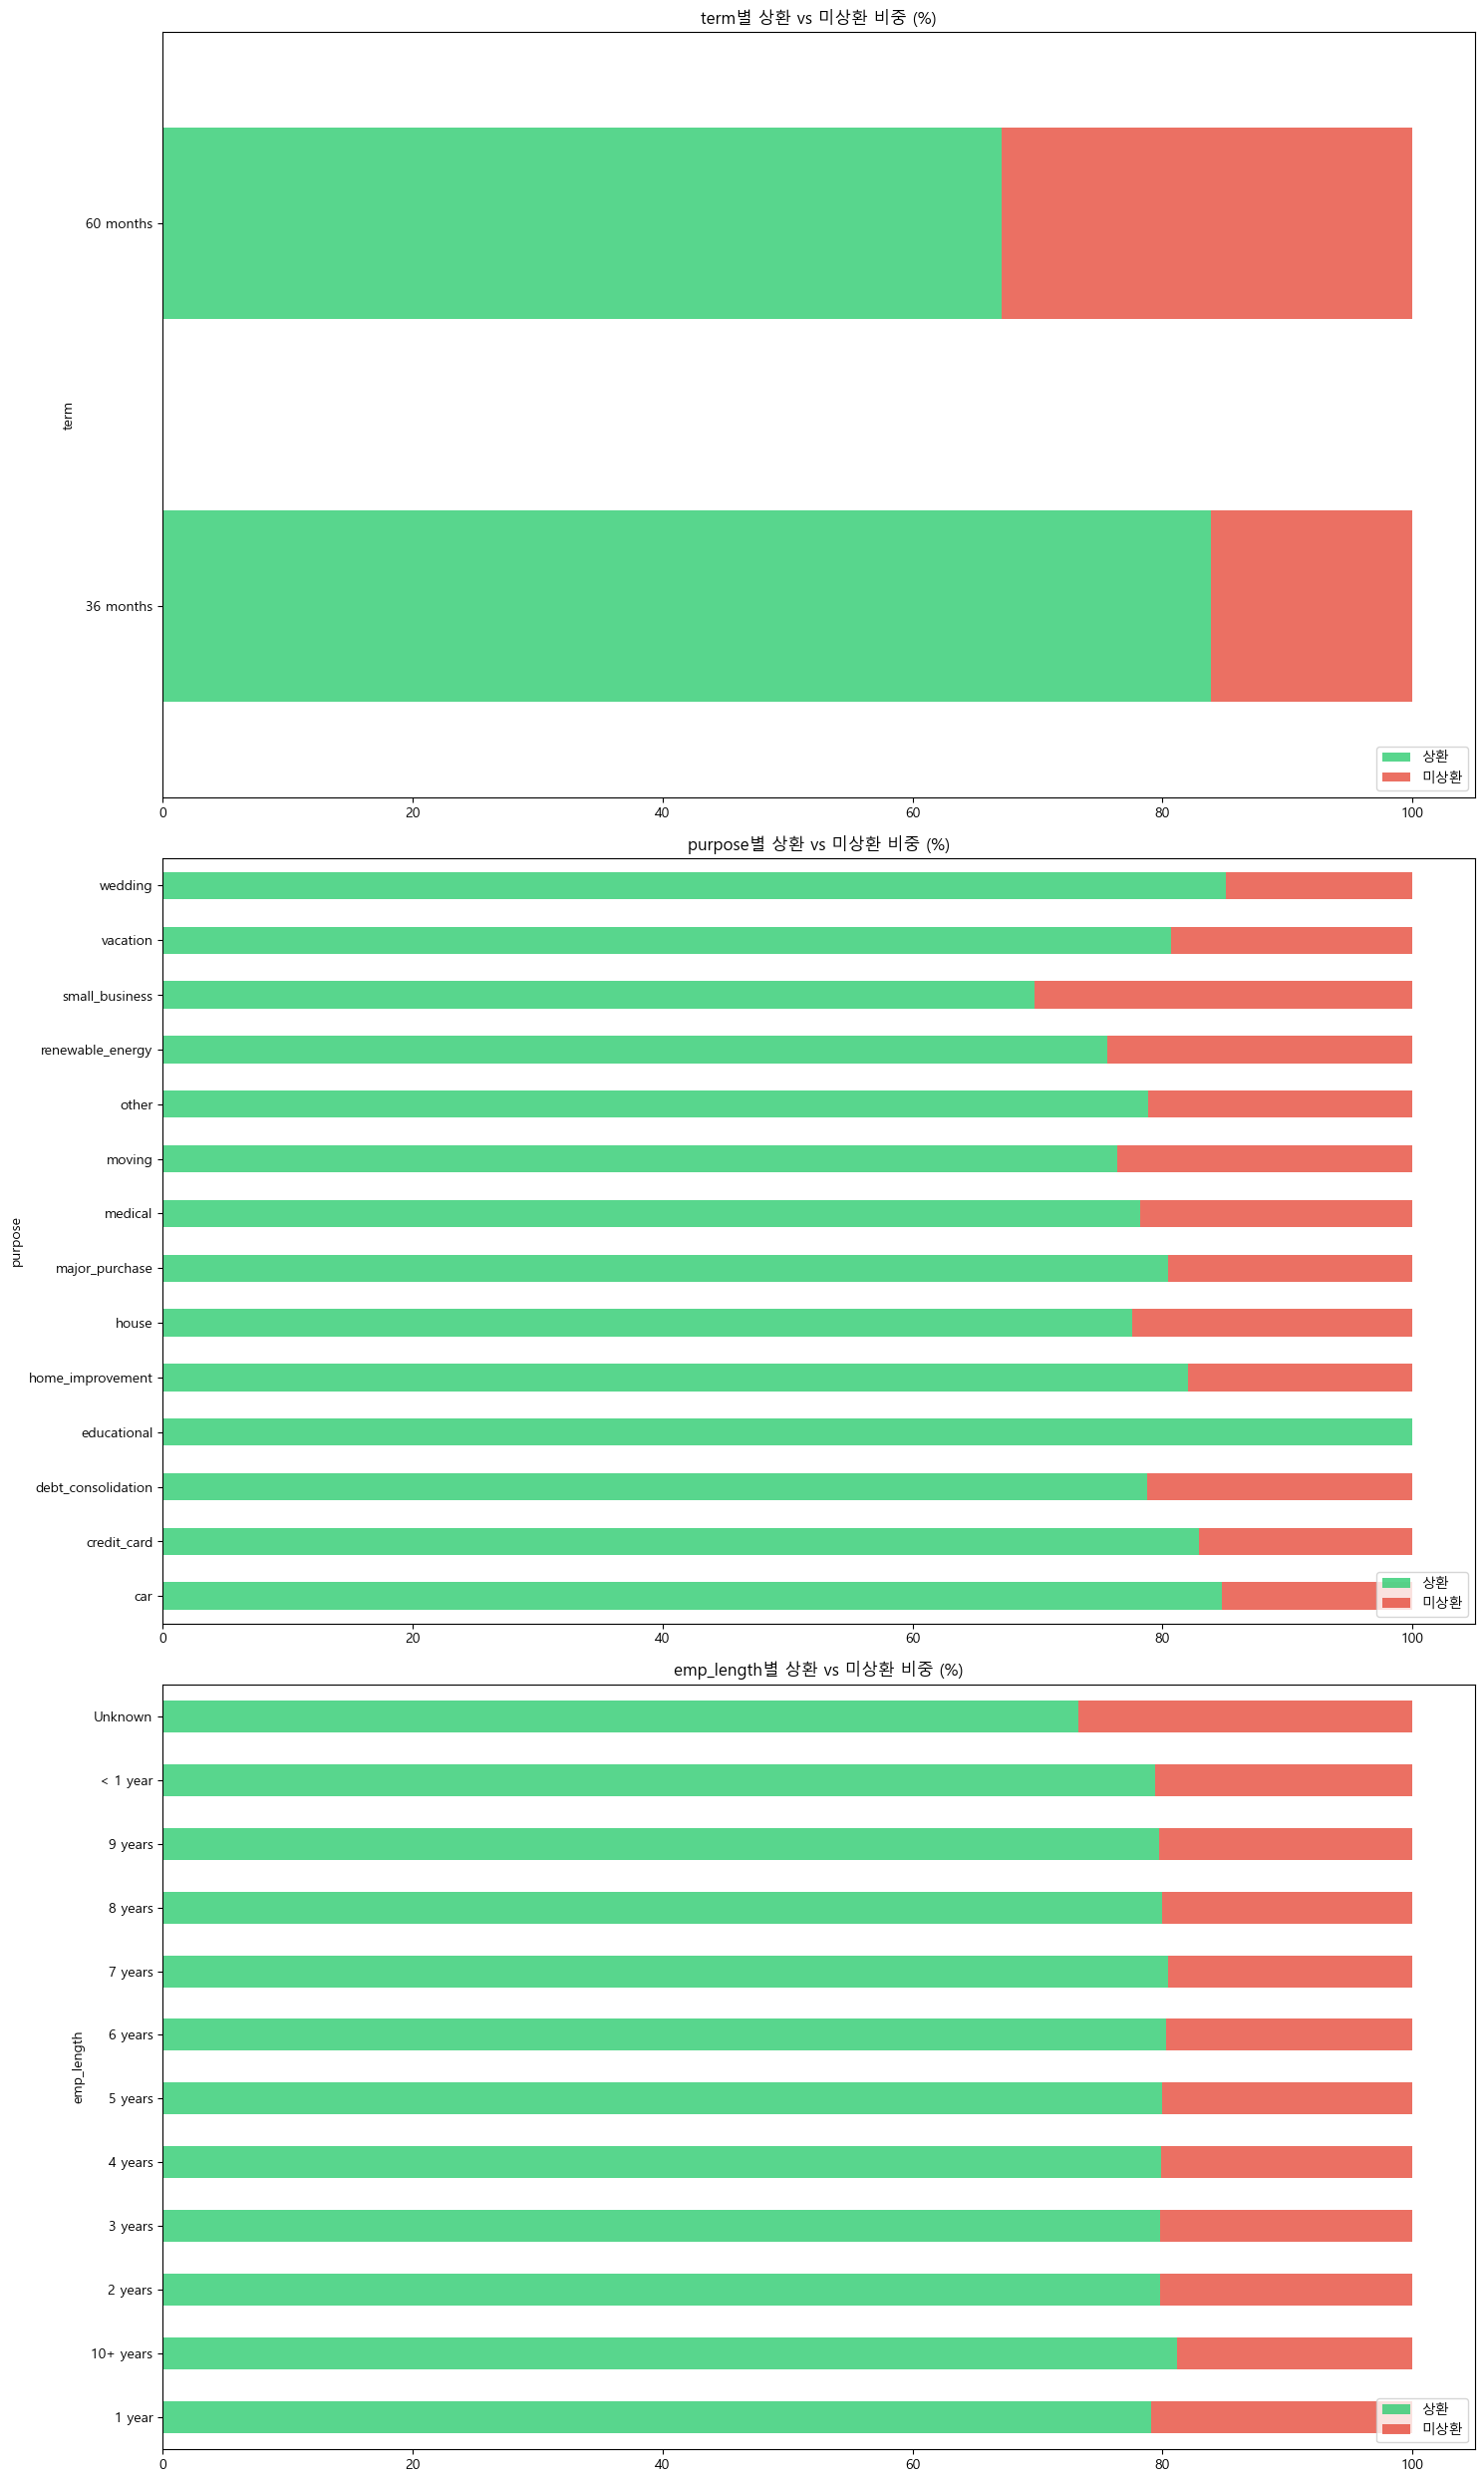

In [210]:
target_cols = ["term", "purpose","emp_length"]

# 그래프 설정
plt.figure(figsize=(15, 25))

for i, col in enumerate(target_cols):
    plt.subplot(len(target_cols), 1, i + 1)
    
    # CASE 1: 범주형 데이터 (글자) -> 상환/미상환 비중 비교
    if col in ["term", "purpose","emp_length"]:
        # 비율 계산
        cross_tab = pd.crosstab(df[col], df['default_rate'], normalize='index') * 100
        # 누적 막대 그래프 (초록: 상환, 빨강: 미상환)
        cross_tab.plot(kind='barh', stacked=True, ax=plt.gca(), color=['#2ecc71', '#e74c3c'], alpha=0.8)
        plt.title(f"{col}별 상환 vs 미상환 비중 (%)")
        plt.legend(["상환", "미상환"], loc='lower right')
        
    # CASE 2: 숫자형 데이터 (금액 등) -> 상환/미상환 분포 비교
    else:
        # 상환 그룹과 미상환 그룹의 분포 차이 시각화
        sns.kdeplot(data=df, x=col, hue='default_rate', fill=True, palette=['#2ecc71', '#e74c3c'])
        plt.title(f"{col} 수치에 따른 상환/미상환 분포")
        plt.legend(["미상환", "상환"]) # hue 순서에 따라 조정

plt.tight_layout()
plt.show()

- 범주형 컬럼으로 미상환율 고객의 특성을 분석해보았을 때, 두드러지게 차이가 나는 컬럼은 대출기간('term')이었다.

## 통계 -가설검정

<br>

- 통계 함수정의

In [211]:
from scipy import stats 
from scipy.stats import chi2_contingency

# cramers_v 함수
def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table).statistic
    n = contingency_table.sum().sum()
    r = contingency_table.shape[0]
    c = contingency_table.shape[1]
    v = np.sqrt(chi2/(n*min(r-1,c-1)))
    return v

# 범주형 미상환율과의 통계-1
def print_valuecount_groupmean_barplot(df, col):
    print(f'{col}별 표본 수')
    display(df[col].value_counts())

    print('='*50)
    print(f'{col}별 미상환율')
    group_mean = df.groupby(col)['default_rate'].mean()
    display(group_mean)
    print('='*50)
    plt.figure(figsize=(6,4))
    sns.barplot(group_mean)
    plt.title(f"{col}에 따른 미상환율")
    plt.ylim(0,1)
    plt.show()
    
# 범주형 미상환율과의 통계-2
def crosstab_chi2_cramersv(df, col):
    print('='*80)
    print('1. 가설설정')
    print(f'- 귀무가설 : {col}과 default_rate는 서로 독립적이다.')
    print(f'- 대립가설 : {col}과 default_rate는 서로 관계가 있다.')
    print('='*80)
    print(f'2. 검정방법 : {col}과 default_rate는 범주x범주 비교로 카이제곱 검정 수행')
    print('='*80)
    print('3. 유의수준 : 0.05')
    print('='*80)
    print('4. 검정통계량 및 p-value 계산')
    print('='*80)
    # 교차표 생성
    print(f'{col}과 default_rate 교차표')
    cont_table = pd.crosstab(df[col], df["default_rate"])
    display(cont_table)
    print('='*80)
    # 카이제곱 검정, 크래머V계수 확인
    chi2 = stats.chi2_contingency(cont_table)
    print('검정통계량 :',chi2[0],'p-value :',chi2[1])
    print('cramers-v 계수: ',cramers_v(cont_table))
    print('='*80)
    print('5. 결론')
    if chi2[1] < 0.05:
        print('p-value가 유의수준 미만으로 귀무가설 기각')
        print(f'결론 : {col}과 default_rate는 서로 관계가 있다.')
        print(f'cramers_v는 {cramers_v(cont_table)}으로 ', end='')
        if (cramers_v(cont_table) >= 0.1) and (cramers_v(cont_table) < 0.3) :
            print('약한 상관관계가 있다.')
        elif cramers_v(cont_table) < 0.1 :
            print('매우 약한 상관관계가 있다.')
        else :
            print('강한 상관관계일 수 있으니 다시 확인.')
    else :
        print('p-value가 유의수준 이상으로 귀무가설 기각하지 못함')
        print(f'결론 : {col}과 default_rate는 서로 독립적이다.(관계가 없다)')

[[ 1. 대출 기간(term) 분석 ]]
term별 표본 수


term
36 months    761693
60 months    239258
Name: count, dtype: int64

term별 미상환율


term
36 months   0.16
60 months   0.33
Name: default_rate, dtype: float64

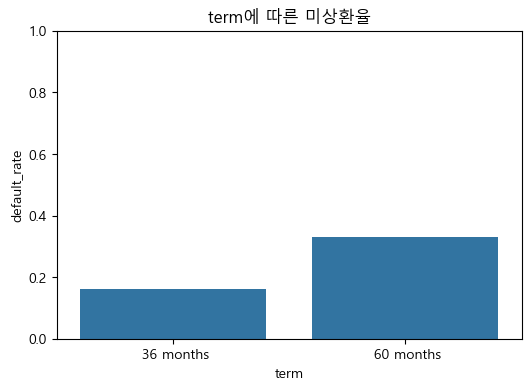

1. 가설설정
- 귀무가설 : term과 default_rate는 서로 독립적이다.
- 대립가설 : term과 default_rate는 서로 관계가 있다.
2. 검정방법 : term과 default_rate는 범주x범주 비교로 카이제곱 검정 수행
3. 유의수준 : 0.05
4. 검정통계량 및 p-value 계산
term과 default_rate 교차표


default_rate,0,1
term,,
36 months,638982,122711
60 months,160535,78723


검정통계량 : 31939.235703729537 p-value : 0.0
cramers-v 계수:  0.17863059746025492
5. 결론
p-value가 유의수준 미만으로 귀무가설 기각
결론 : term과 default_rate는 서로 관계가 있다.
cramers_v는 0.17863059746025492으로 약한 상관관계가 있다.


 --------------------------------------------------------------------------------
[[ 2. 대출목적 분석 ]]
purpose별 표본 수


purpose
debt_consolidation    583909
credit_card           224102
home_improvement       64796
other                  56565
major_purchase         20773
medical                11241
small_business          9950
car                     9760
moving                  6754
vacation                6678
house                   5117
wedding                  691
renewable_energy         614
educational                1
Name: count, dtype: int64

purpose별 미상환율


purpose
car                  0.15
credit_card          0.17
debt_consolidation   0.21
educational          0.00
home_improvement     0.18
house                0.22
major_purchase       0.20
medical              0.22
moving               0.24
other                0.21
renewable_energy     0.24
small_business       0.30
vacation             0.19
wedding              0.15
Name: default_rate, dtype: float64

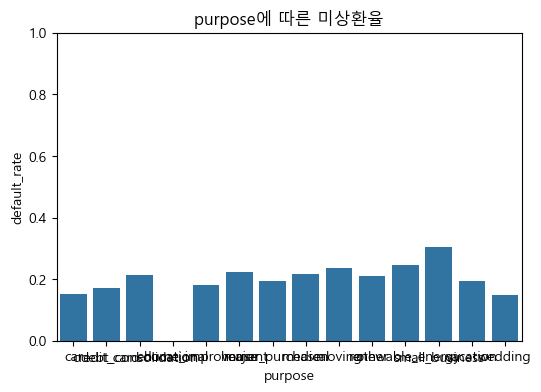

1. 가설설정
- 귀무가설 : purpose과 default_rate는 서로 독립적이다.
- 대립가설 : purpose과 default_rate는 서로 관계가 있다.
2. 검정방법 : purpose과 default_rate는 범주x범주 비교로 카이제곱 검정 수행
3. 유의수준 : 0.05
4. 검정통계량 및 p-value 계산
purpose과 default_rate 교차표


default_rate,0,1
purpose,,
car,8272,1488
credit_card,185785,38317
debt_consolidation,459706,124203
educational,1,0
home_improvement,53141,11655
house,3969,1148
major_purchase,16714,4059
medical,8790,2451
moving,5159,1595


검정통계량 : 2871.432133018126 p-value : 0.0
cramers-v 계수:  0.05356028375128709
5. 결론
p-value가 유의수준 미만으로 귀무가설 기각
결론 : purpose과 default_rate는 서로 관계가 있다.
cramers_v는 0.05356028375128709으로 매우 약한 상관관계가 있다.


 --------------------------------------------------------------------------------
[[ 3. 근속기간 분석 ]]
purpose별 표본 수


purpose
debt_consolidation    583909
credit_card           224102
home_improvement       64796
other                  56565
major_purchase         20773
medical                11241
small_business          9950
car                     9760
moving                  6754
vacation                6678
house                   5117
wedding                  691
renewable_energy         614
educational                1
Name: count, dtype: int64

purpose별 미상환율


purpose
car                  0.15
credit_card          0.17
debt_consolidation   0.21
educational          0.00
home_improvement     0.18
house                0.22
major_purchase       0.20
medical              0.22
moving               0.24
other                0.21
renewable_energy     0.24
small_business       0.30
vacation             0.19
wedding              0.15
Name: default_rate, dtype: float64

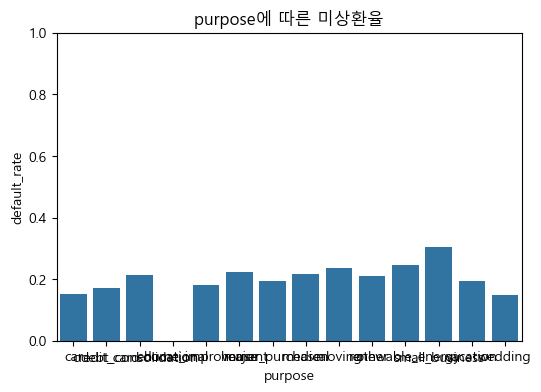

1. 가설설정
- 귀무가설 : purpose과 default_rate는 서로 독립적이다.
- 대립가설 : purpose과 default_rate는 서로 관계가 있다.
2. 검정방법 : purpose과 default_rate는 범주x범주 비교로 카이제곱 검정 수행
3. 유의수준 : 0.05
4. 검정통계량 및 p-value 계산
purpose과 default_rate 교차표


default_rate,0,1
purpose,,
car,8272,1488
credit_card,185785,38317
debt_consolidation,459706,124203
educational,1,0
home_improvement,53141,11655
house,3969,1148
major_purchase,16714,4059
medical,8790,2451
moving,5159,1595


검정통계량 : 2871.432133018126 p-value : 0.0
cramers-v 계수:  0.05356028375128709
5. 결론
p-value가 유의수준 미만으로 귀무가설 기각
결론 : purpose과 default_rate는 서로 관계가 있다.
cramers_v는 0.05356028375128709으로 매우 약한 상관관계가 있다.


 --------------------------------------------------------------------------------
[[ 4. 주거형태 분석 ]]
home_ownership별 표본 수


home_ownership
MORTGAGE    494563
RENT        396306
OWN         109780
OTHER          302
Name: count, dtype: int64

home_ownership별 미상환율


home_ownership
MORTGAGE   0.17
OTHER      0.19
OWN        0.21
RENT       0.24
Name: default_rate, dtype: float64

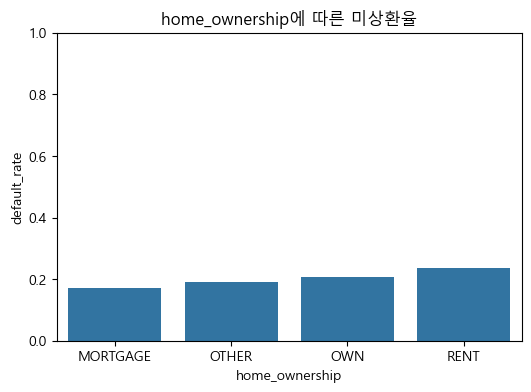

1. 가설설정
- 귀무가설 : home_ownership과 default_rate는 서로 독립적이다.
- 대립가설 : home_ownership과 default_rate는 서로 관계가 있다.
2. 검정방법 : home_ownership과 default_rate는 범주x범주 비교로 카이제곱 검정 수행
3. 유의수준 : 0.05
4. 검정통계량 및 p-value 계산
home_ownership과 default_rate 교차표


default_rate,0,1
home_ownership,,
MORTGAGE,409284,85279
OTHER,244,58
OWN,87213,22567
RENT,302776,93530


검정통계량 : 5545.786870653241 p-value : 0.0
cramers-v 계수:  0.07443465482011133
5. 결론
p-value가 유의수준 미만으로 귀무가설 기각
결론 : home_ownership과 default_rate는 서로 관계가 있다.
cramers_v는 0.07443465482011133으로 매우 약한 상관관계가 있다.


In [212]:
print("[[ 1. 대출 기간(term) 분석 ]]")
print_valuecount_groupmean_barplot(df, 'term')
crosstab_chi2_cramersv(df, 'term')
print('\n\n','-'*80)

print("[[ 2. 대출목적 분석 ]]")
print_valuecount_groupmean_barplot(df, 'purpose')
crosstab_chi2_cramersv(df, 'purpose')
print('\n\n','-'*80)

print("[[ 3. 근속기간 분석 ]]")
print_valuecount_groupmean_barplot(df, 'purpose')
crosstab_chi2_cramersv(df, 'purpose')
print('\n\n','-'*80)
print("[[ 4. 주거형태 분석 ]]")
print_valuecount_groupmean_barplot(df, 'home_ownership')
crosstab_chi2_cramersv(df, 'home_ownership')

- - 'term'은 미상환율과 연관성이 있는 것으로 확인되었고 '약한 상관관계'이다.
- 근무기간(emp_length)과 대출목적(purpose) 또한 미상환율과 연관성이 있지만 '매우 약한 상관관계'이다.

- 비교적 대출기간(term)이 미상환율의 특성을 크게 나타낼 수 있는 큰 지표임을 확인.

- => “약한상관관계를 나타낸 지표는 그 지표만으로는 영향이 크지 않기에 emp_length와 purpose를
보조지표로써 상관관계가 높은 term과 함께 보았을 때 그 영향이 확실히 나타난다.”

----------------------------------------------
#### 근속기간과 term 함께 리스크율 비교

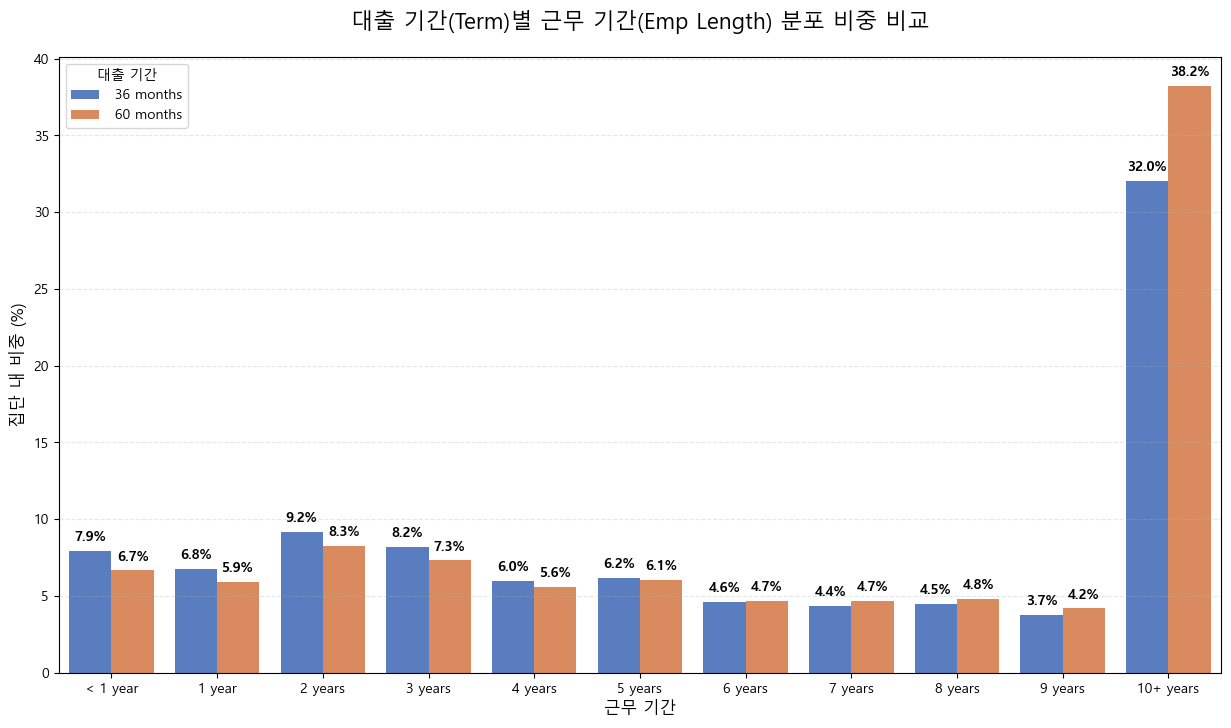

In [213]:
ratio_df = df.groupby(['term', 'emp_length']).size().unstack(level=0)
ratio_df = (ratio_df / ratio_df.sum()) * 100  # 각 컬럼(term) 합계를 100으로 환산
ratio_df = ratio_df.reset_index()

emp_order = ['< 1 year', '1 year', '2 years', '3 years', '4 years', '5 years', 
             '6 years', '7 years', '8 years', '9 years', '10+ years']

ratio_melted = ratio_df.melt(id_vars='emp_length', var_name='term', value_name='percentage')
ratio_melted['emp_length'] = pd.Categorical(ratio_melted['emp_length'], categories=emp_order, ordered=True)
ratio_melted = ratio_melted.sort_values('emp_length')

plt.figure(figsize=(15, 8))
ax = sns.barplot(x='emp_length', y='percentage', hue='term', data=ratio_melted, palette='muted')

for p in ax.patches:
    if p.get_height() > 0: # 0%가 아닌 경우만 표시
        ax.annotate(f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.title('대출 기간(Term)별 근무 기간(Emp Length) 분포 비중 비교', fontsize=16, pad=20)
plt.ylabel('집단 내 비중 (%)', fontsize=12)
plt.xlabel('근무 기간', fontsize=12)
plt.legend(title='대출 기간')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

- 대출기간('term') X 근무기간('emp_length') 교차표 생성

- 근무기간의 경우, 비슷한 특성을 가진 표본끼리 묶어 '저연차, 중간, 중상, 고연차' 그룹으로 새로 컬럼 생성 ('emp_group')

10년+을 제외하고 표본수가 너무 적기에 저연차/중간/중상/고연차로 묶기

emp_group 묶기
--> 0-2년(저연차)
    3-5년(중간)	
    6-9년(중상)	
    10년+(고연차)

------------------------------------------------

대출기간(term) X 근무기간(emp_length) 미상환율 리스크 점수 

In [214]:
# 1. 근무 기간(emp_length) 그룹화 (Binning)

def group_emp_length(x):
    if x in ['< 1 year', '1 year', '2 years']: return '0-2년(저연차)'
    elif x in ['3 years', '4 years', '5 years']: return '3-5년(중간)'
    elif x in ['6 years', '7 years', '8 years', '9 years']: return '6-9년(중상)'
    elif x == '10+ years': return '10년+(고연차)'
    else : return 'Unknown'

df['emp_group'] = df['emp_length'].apply(group_emp_length)

# 2. 교차표 생성
# 각 셀의 표본 수(count)와 실제 미상환율(mean) 계산
# mean =  '해당 조건 집단의 순수 미상환율' = 미상환자 수 / 전체 고객 수
cross_risk = df.groupby(['emp_group', 'term'])['default_rate'].agg(['count', 'mean']).reset_index()

# 3. 표 형식 변환
# n (표본 수) 표
n_table = cross_risk.pivot(index='emp_group', columns='term', values='count')
# bad_rate (실제 미상환율) 표
bad_rate_table = cross_risk.pivot(index='emp_group', columns='term', values='mean')


# 1. 행/열 고정
group_order = ['0-2년(저연차)', '3-5년(중간)', '6-9년(중상)','10년+(고연차)']
term_order = ['36 months',	'60 months']

# 3. 행과 열을 동시에 고정 (reindex 사용)
n_table = n_table.reindex(index = group_order)
bad_rate_table = bad_rate_table.reindex(index = group_order)




# 4. 결과 통합 출력 (이미지와 동일)
final_matrix = pd.concat([n_table, bad_rate_table], axis=1, keys=['표본 수(n)', '실제 미상환율(bad_rate)'])
display(final_matrix)

표본 수(n)           실제 미상환율(bad_rate)          
term      36 months 60 months         36 months 60 months
emp_group                                                
0-2년(저연차)    182089     49858              0.17      0.35
3-5년(중간)     155065     45390              0.16      0.34
6-9년(중상)     130983     43960              0.16      0.33
10년+(고연차)    244005     91446              0.14      0.31

- 다른 특성중 소득대비대출금 또한 term에 의한 차이가 존재하는지 확인

In [215]:
df.groupby('term')['loan_income_ratio'].mean()

term
36 months   0.19
60 months   0.28
Name: loan_income_ratio, dtype: float64

- 대출기간에 의하여 각 특성별 차이를 반영하기 위해 텀별로 그룹화하여 각 특성의 미상환율 계산

--------------------------------------------------

#### 대출 입력정보 기반 term별 리스크점수 파생컬럼

In [216]:
# term별로 연속형 변수인 소득대비대출금 구간화 후 구간별 평균 미상환율 계산 - 다른 기준으로 할 시 term을 수정 후 적용할 컬럼을 넣으시면 됩니다.
def continuous_by_term_train_test(col):
    # 기존 컬럼이 있으면 제거
    for target_df in [df, test_df]:
        for c in [f"{col}_bin", f"{col}_risk_score"]:
            if c in target_df.columns:
                target_df.drop(columns=c, inplace=True)

    # 초기화
    df[f"{col}_bin"] = np.nan
    df[f"{col}_risk_score"] = np.nan
    test_df[f"{col}_bin"] = np.nan
    test_df[f"{col}_risk_score"] = np.nan

    term_list = df['term'].dropna().unique().tolist()
    risk_table_list = []

    for t in term_list:
        # -------------------------
        # 1) df에서 해당 term만 추출
        # -------------------------
        temp_train = df[df["term"] == t].copy()

        if temp_train.empty:
            continue

        # -------------------------
        # 2) df에서 qcut 경계값 학습
        # -------------------------
        train_bins, bin_edges = pd.qcut(
            temp_train[col],
            q=10,
            duplicates='drop',
            retbins=True
        )

        temp_train[f"{col}_bin"] = train_bins.astype(str)

        # -------------------------
        # 3) df에서 term별 bin 평균 미상환율 계산
        # -------------------------
        temp_risk_table = (
            temp_train.groupby(f"{col}_bin", observed=False)["default_rate"]
            .mean()
            .reset_index()
            .rename(columns={"default_rate": f"{col}_risk_score"})
        )
        temp_risk_table["term"] = t

        risk_table_list.append(temp_risk_table)

        # -------------------------
        # 4) df에 bin / score 반영
        # -------------------------
        risk_map = dict(zip(
            temp_risk_table[f"{col}_bin"],
            temp_risk_table[f"{col}_risk_score"]
        ))

        df.loc[temp_train.index, f"{col}_bin"] = temp_train[f"{col}_bin"]
        df.loc[temp_train.index, f"{col}_risk_score"] = temp_train[f"{col}_bin"].map(risk_map)

        # -------------------------
        # 5) test_df에 같은 경계값 적용
        # -------------------------
        temp_test = test_df[test_df["term"] == t].copy()

        if temp_test.empty:
            continue

        temp_test[f"{col}_bin"] = pd.cut(
            temp_test[col],
            bins=bin_edges,
            include_lowest=True
        ).astype(str)

        test_df.loc[temp_test.index, f"{col}_bin"] = temp_test[f"{col}_bin"]
        test_df.loc[temp_test.index, f"{col}_risk_score"] = temp_test[f"{col}_bin"].map(risk_map)

    # 전체 risk table 반환
    if risk_table_list:
        risk_table = pd.concat(risk_table_list, ignore_index=True)
    else:
        risk_table = pd.DataFrame(columns=["term", f"{col}_bin", f"{col}_risk_score"])

    return risk_table

#term별로 범주형 변수 평균 미상환율 계산
def category_by_term_risk_train_test(col):
    # 기존 컬럼 제거
    for target_df in [df, test_df]:
        if f"{col}_risk_score" in target_df.columns:
            target_df.drop(columns=[f"{col}_risk_score"], inplace=True)

    # 초기화
    df[f"{col}_risk_score"] = np.nan
    test_df[f"{col}_risk_score"] = np.nan

    term_list = df['term'].dropna().unique().tolist()
    risk_table_list = []

    for t in term_list:
        # -------------------------
        # 1) df에서 해당 term만 추출
        # -------------------------
        temp_train = df[df["term"] == t].copy()

        if temp_train.empty:
            continue

        # -------------------------
        # 2) df에서 term별 category 평균 미상환율 계산
        # -------------------------
        temp_risk_table = (
            temp_train.groupby(col, dropna=False)["default_rate"]
            .mean()
            .reset_index()
            .rename(columns={"default_rate": f"{col}_risk_score"})
        )
        temp_risk_table["term"] = t

        risk_table_list.append(temp_risk_table)

        risk_map = dict(zip(
            temp_risk_table[col],
            temp_risk_table[f"{col}_risk_score"]
        ))

        # -------------------------
        # 3) df에 반영
        # -------------------------
        df.loc[temp_train.index, f"{col}_risk_score"] = temp_train[col].map(risk_map)

        # -------------------------
        # 4) test_df에 같은 규칙 적용
        # -------------------------
        temp_test = test_df[test_df["term"] == t].copy()

        if temp_test.empty:
            continue

        test_df.loc[temp_test.index, f"{col}_risk_score"] = temp_test[col].map(risk_map)

    # 전체 risk table 반환
    if risk_table_list:
        risk_table = pd.concat(risk_table_list, ignore_index=True)
    else:
        risk_table = pd.DataFrame(columns=["term", col, f"{col}_risk_score"])

    return risk_table

# 연소득 대비 대출신청금
loan_income_ratio_risk_table = continuous_by_term_train_test('loan_income_ratio')

# 주거형태
home_ownership_risk_table = category_by_term_risk_train_test('home_ownership')

# 대출목적
purpose_risk_table = category_by_term_risk_train_test('purpose')

# 근속기간
emp_length_group_risk_table = category_by_term_risk_train_test('emp_length_group')

C:\Users\gkdlw\AppData\Local\Temp\ipykernel_46000\2712591974.py:60: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['(0.00186, 0.0667]' '(0.284, 0.345]' '(0.147, 0.174]' ...
 '(0.0667, 0.096]' '(0.174, 0.201]' '(0.284, 0.345]']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[temp_train.index, f"{col}_bin"] = temp_train[f"{col}_bin"]
C:\Users\gkdlw\AppData\Local\Temp\ipykernel_46000\2712591974.py:77: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['(0.284, 0.345]' '(0.0667, 0.096]' '(0.201, 0.239]' ... '(0.0667, 0.096]'
 '(0.147, 0.174]' '(0.284, 0.345]']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  test_df.loc[temp_test.index, f"{col}_bin"] = temp_test[f"{col}_bin"]


-----------------------------

### 리스크 스코어 합산 파생컬럼

In [217]:
#total_risk_score 계산

risk_cols = []
for i in df.columns.to_list():
    if '_risk_score' in i:
        risk_cols.append(i)

print(risk_cols)

df['total_risk_score'] = 0
for i in risk_cols:
    df['total_risk_score'] += df[i]

test_df['total_risk_score'] = 0
for i in risk_cols:
    test_df['total_risk_score'] += test_df[i]

display(df['total_risk_score'].describe())

['revol_util_risk_score', 'inq_last_6mths_risk_score', 'avg_bal_per_acc_risk_score', 'dti_risk_score', 'tot_cur_bal_risk_score', 'percent_bc_gt_75_risk_score', 'loan_income_ratio_risk_score', 'home_ownership_risk_score', 'purpose_risk_score', 'emp_length_group_risk_score']


count   1000951.00
mean          2.01
std           0.40
min           0.83
25%           1.80
50%           1.92
75%           2.28
max           3.33
Name: total_risk_score, dtype: float64

-------------------------------------------------------------------------------------
#### Train/test data 저장

In [218]:
df_score_risk = df.copy()

In [219]:
df_score_risk.to_csv('df__risk_score.csv', index = False)

In [220]:
test_df.to_csv('test_df.csv', index=False)